In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import OrderedDict

In [2]:
mybl_lang = pd.read_csv('mybl_lang.csv')
mybl_lang = mybl_lang.loc[mybl_lang['name'] != 'Swift']
mybl_lang.drop('id', axis=1, inplace=True)

In [3]:
langs = mybl_lang.pivot(index='date_added', columns='name', values=['val', 'val_noexp', 'res_vac'])
langs.dropna(inplace=True)

In [4]:
Mind = pd.MultiIndex.from_tuples([('res', i) for i in langs['val'].columns])
langs_res = langs['res_vac'] * langs['val']
langs_res.columns = Mind
langs = pd.merge(langs, langs_res, how='left', on='date_added')

In [5]:
#normalization
for i in langs.columns:
    langs[i] = langs[i]/(max(langs[i]))

langs.describe()

val                                                        \
                1c         ABAP      Android Data scientist       DevOps   
count  1315.000000  1315.000000  1315.000000    1315.000000  1315.000000   
mean      0.773717     0.383886     0.514402       0.698881     0.642068   
std       0.111615     0.262654     0.229903       0.148160     0.117521   
min       0.556527     0.105000     0.242900       0.413926     0.398362   
25%       0.669759     0.180000     0.338369       0.568665     0.547282   
50%       0.758346     0.245000     0.398187       0.727273     0.618392   
75%       0.869824     0.660000     0.783988       0.823017     0.722264   
max       1.000000     1.000000     1.000000       1.000000     1.000000   

                                                                        ...  \
          Frontend       Golang         Java   Javascript       Python  ...   
count  1315.000000  1315.000000  1315.000000  1315.000000  1315.000000  ...   
mean      0.536722     0.742003     0.558522     0.537684     0.637075  ...   
std       0.217814     0.137263     0.188660     0.214598     0.136867  ...   
min       0.282471     0.473684     0.291237     0.300840     0.407917  ...   
25%       0.373976     0.623090     0.422688     0.375000     0.545181  ...   
50%       0.406038     0.726655     0.477268     0.412780     0.583046  ...   
75%       0.775568     0.877759     0.753459     0.785914     0.728485  ...   
max       1.000000     1.000000     1.000000     1.000000     1.000000  ...   

               res                                                      \
            Golang         Java   Javascript       Python         Ruby   
count  1315.000000  1315.000000  1315.000000  1315.000000  1315.000000   
mean      0.418785     0.695928     0.753904     0.617234     0.789060   
std       0.237833     0.158591     0.136169     0.222673     0.105488   
min       0.112078     0.450515     0.515625     0.268730     0.636880   
25%       0.173614     0.527310     0.626205     0.383967     0.684227   
50%       0.390529     0.702048     0.770938     0.638721     0.783126   
75%       0.604179     0.824627     0.861233     0.821596     0.873923   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                                                                        
             Scala          cpp           cs          iOS          php  
count  1315.000000  1315.000000  1315.000000  1315.000000  1315.000000  
mean      0.738158     0.688816     0.759132     0.709563     0.757690  
std       0.129169     0.147073     0.137164     0.178990     0.107856  
min       0.501567     0.475950     0.532802     0.424123     0.608599  
25%       0.634927     0.549260     0.610722     0.517437     0.653279  
50%       0.758882     0.679984     0.782429     0.738378     0.741961  
75%       0.817529     0.811943     0.880680     0.865087     0.838281  
max       1.000000     1.000000     1.000000     1.000000     1.000000  

[8 rows x 64 columns]

([<matplotlib.axis.XTick at 0x1b8e44c5450>,
 [Text(281.0, 0, '2022-01-01'), Text(646.0, 0, '2023-01-01')])

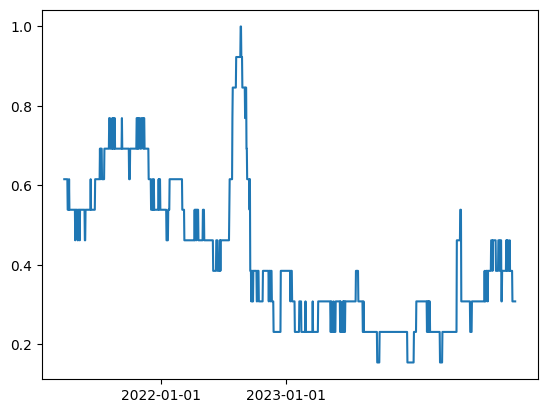

In [6]:
plt.plot(langs["val_noexp", "cpp"])
plt.xticks(['2022-01-01', '2023-01-01'])

In [7]:
def graphs(column, window):
    colmns = langs[column].columns

    langs1 = langs[column].copy()
    langs2 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        langs2[i] = langs2[i].rolling(window=window).mean()
        langs2[i] = langs2[i].shift(window)

        if col[:2] != 'Py':
            ax.plot(langs1[i] - langs2[i])
            labels.append(langs2[i].name)
            col = i
        else:
            ax.plot(langs1[i] - langs2[i], linestyle='--')
            labels.append(langs2[i].name)
            col = 'Py'

    ax.legend(labels, loc='upper left')
    ax.axhline(y=0, color='k')
    plt.xticks('')
    #ax.set_xticklabels((date), rotation=90)

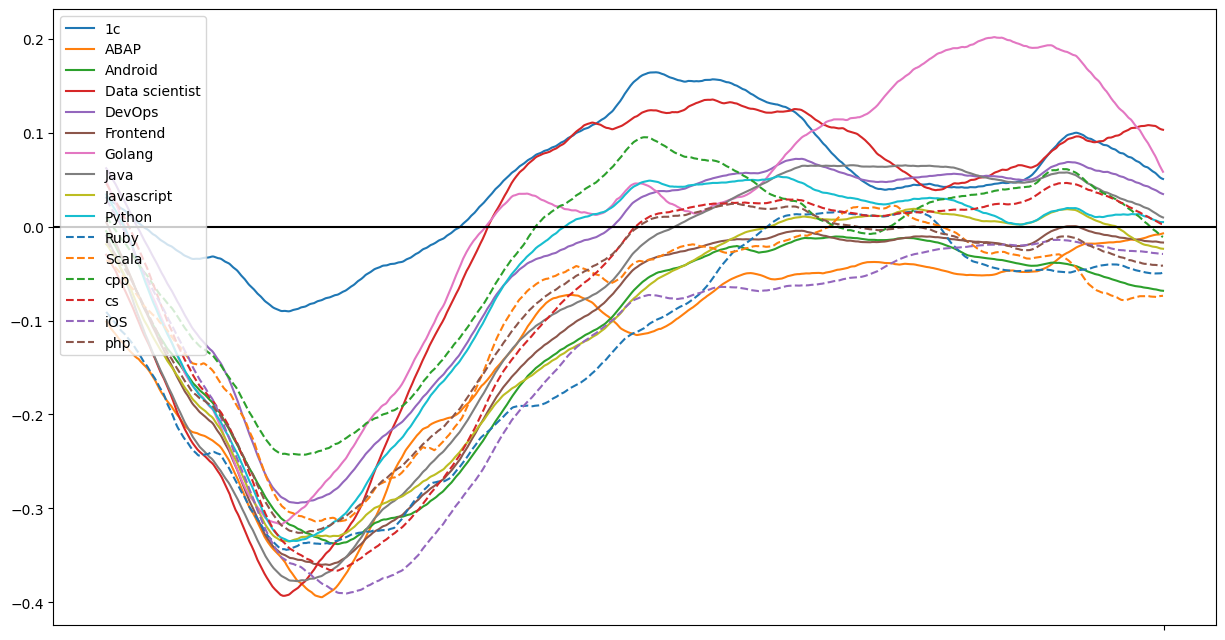

In [8]:
graphs('val', 200)

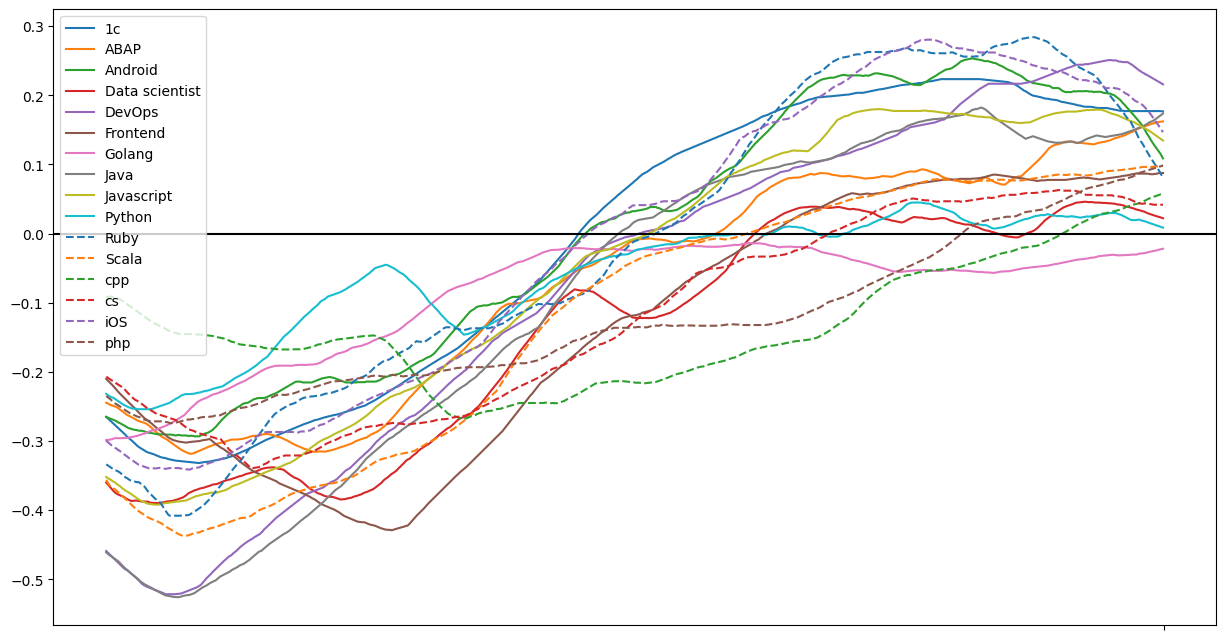

In [9]:
graphs('val_noexp', 300)

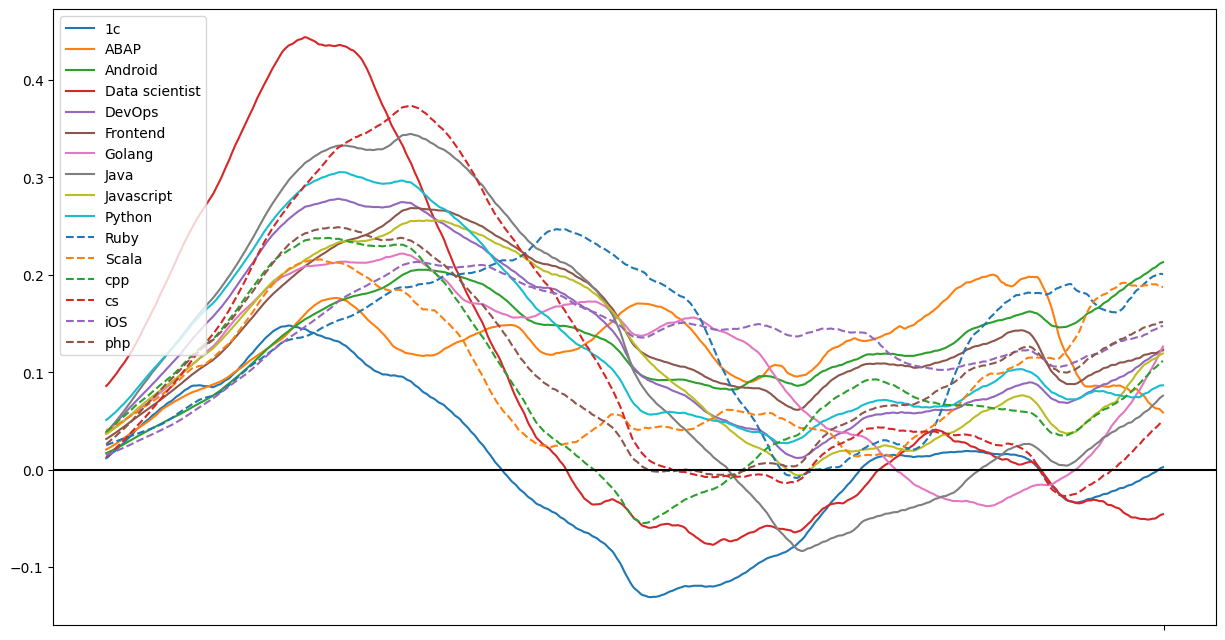

In [10]:
graphs('res_vac', 200)

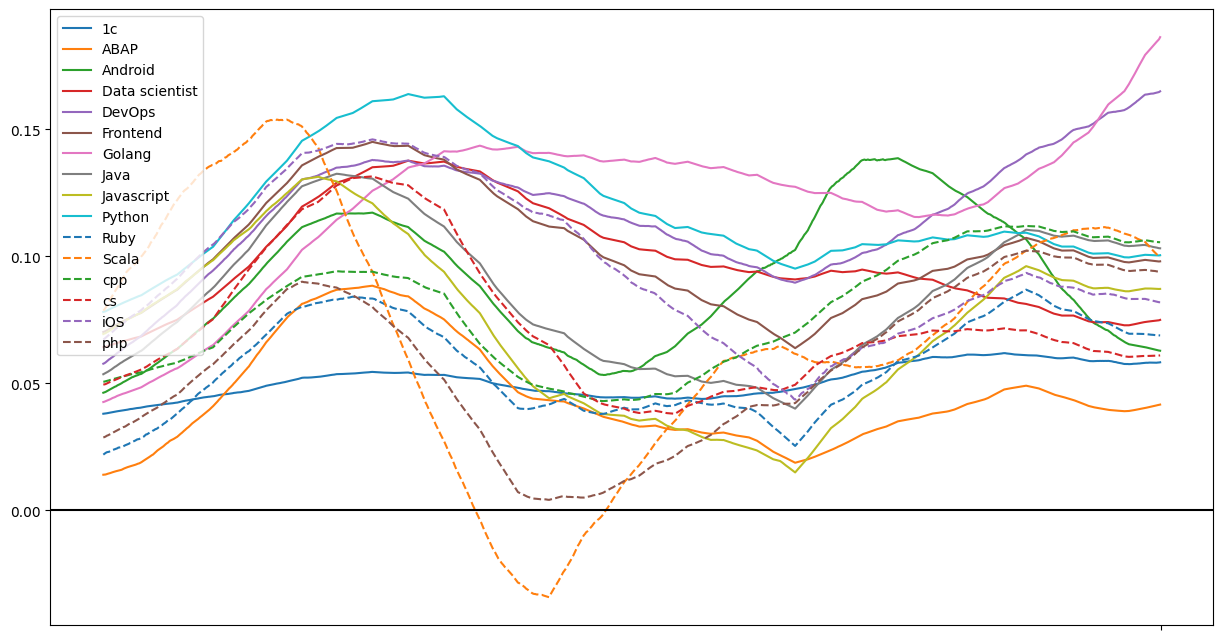

In [11]:
graphs('res', 200)

In [12]:
langs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1315 entries, 2021-03-26 to 2024-11-01
Data columns (total 64 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   (val, 1c)                    1315 non-null   float64
 1   (val, ABAP)                  1315 non-null   float64
 2   (val, Android)               1315 non-null   float64
 3   (val, Data scientist)        1315 non-null   float64
 4   (val, DevOps)                1315 non-null   float64
 5   (val, Frontend)              1315 non-null   float64
 6   (val, Golang)                1315 non-null   float64
 7   (val, Java)                  1315 non-null   float64
 8   (val, Javascript)            1315 non-null   float64
 9   (val, Python)                1315 non-null   float64
 10  (val, Ruby)                  1315 non-null   float64
 11  (val, Scala)                 1315 non-null   float64
 12  (val, cpp)                   1315 non-null   float64
 13  (val, cs

In [13]:
import seaborn as sns

def corr(colmns):
    plt.figure(figsize=(10,10))
    sns.set(font_scale=1.0)
    sns.heatmap(pd.DataFrame(langs[colmns]).corr(),cmap='GnBu',annot=True)

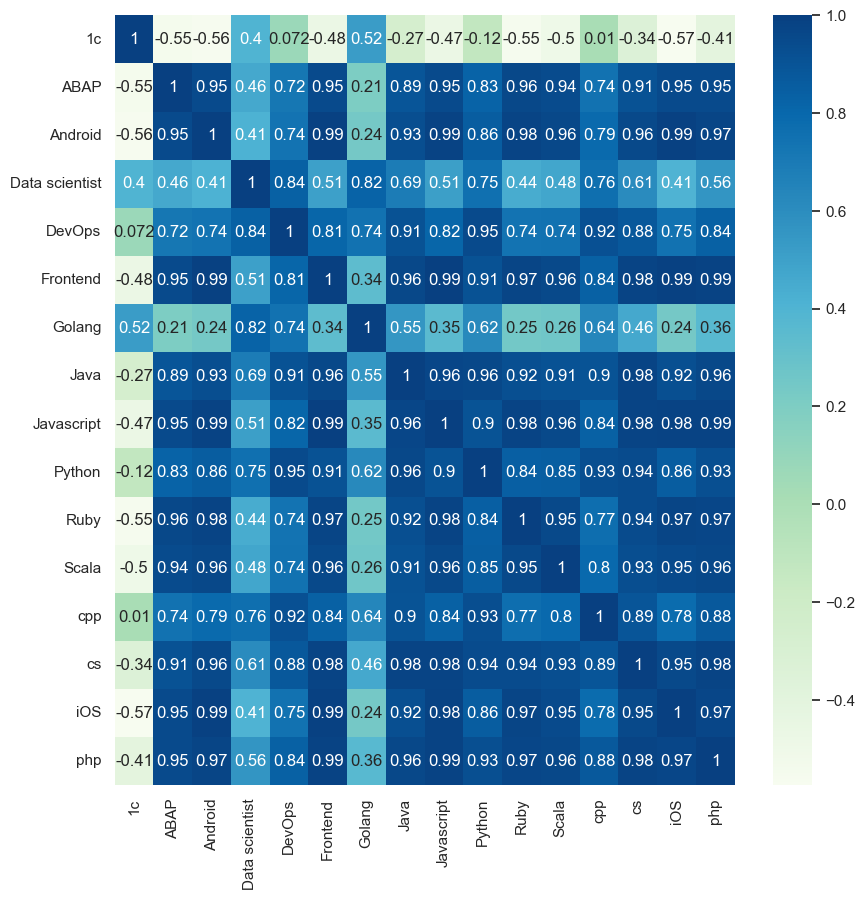

In [14]:
corr('val')

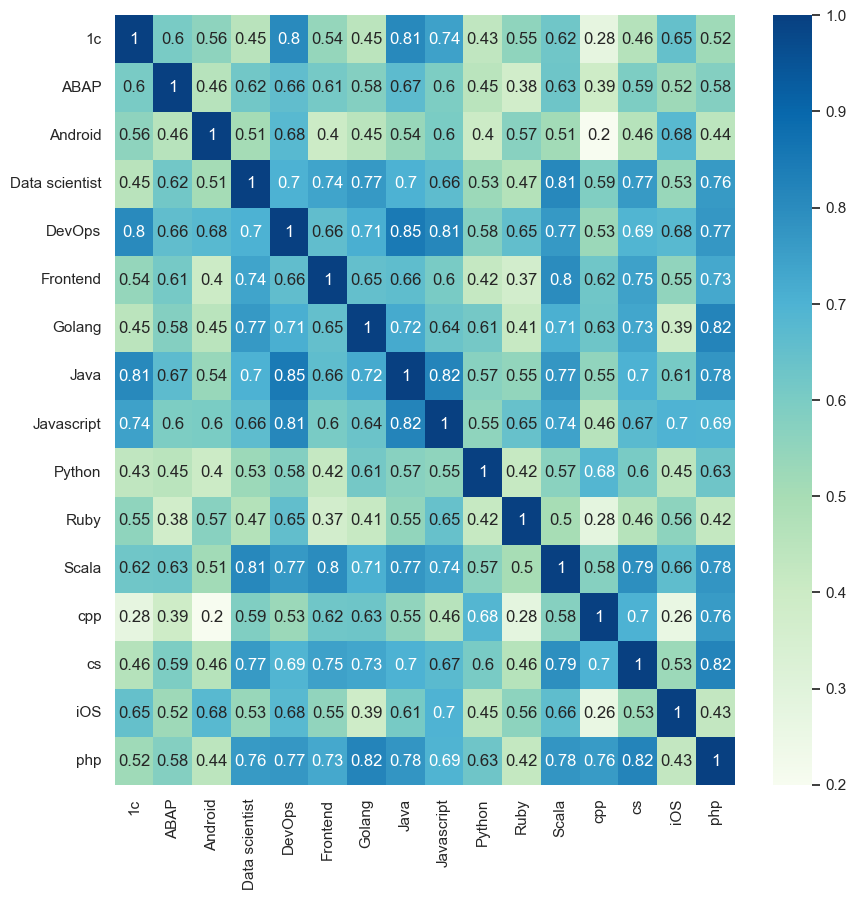

In [15]:
corr('val_noexp')

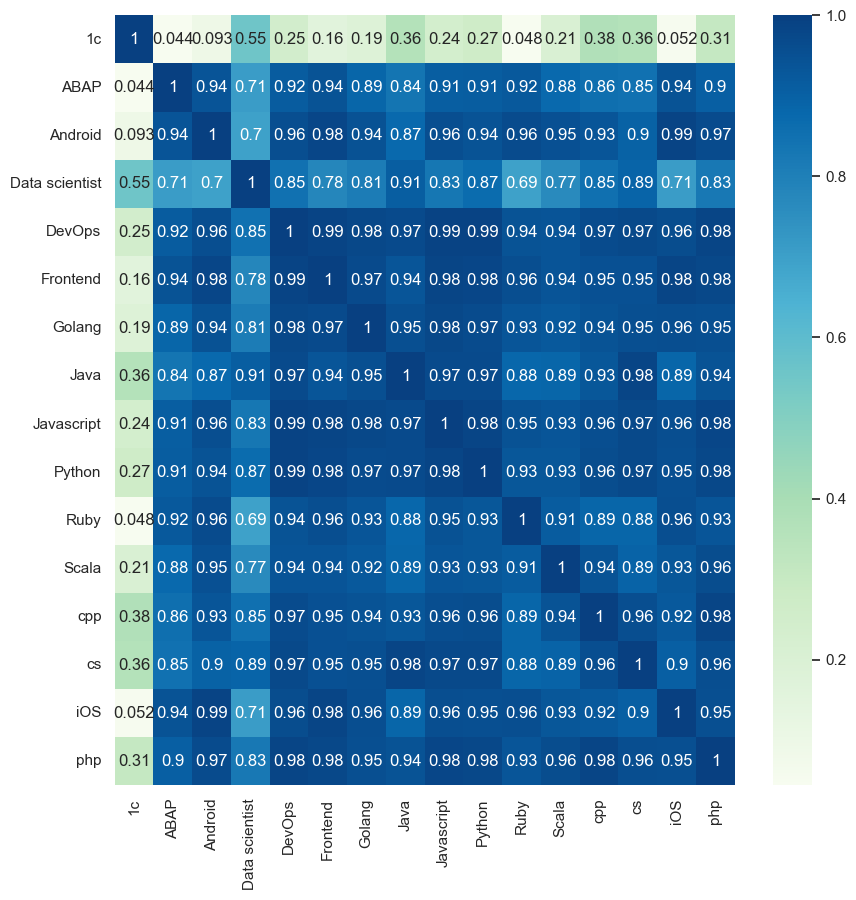

In [16]:
corr('res_vac')

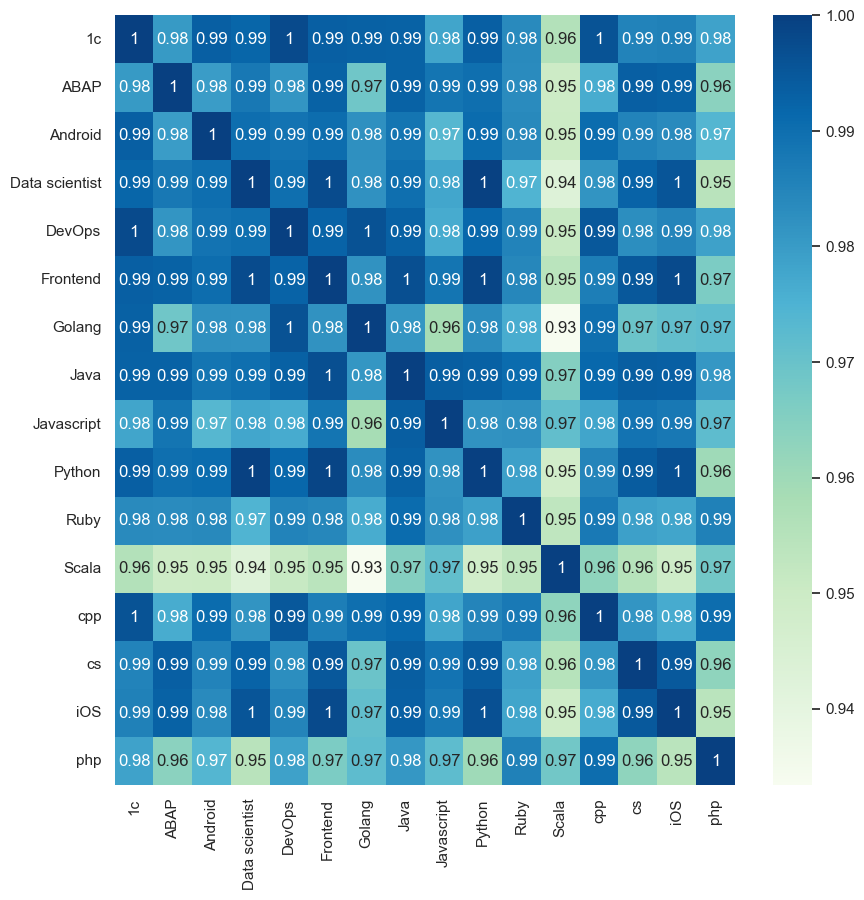

In [17]:
corr('res')

In [18]:
langs.index = pd.to_datetime(langs.index)

def year(x):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    plt.plot(langs[x].groupby(langs.index.strftime('%m-%d')).median().median(axis=1))
    plt.xticks([str(i).zfill(2) + "-01" for i in range(1, 13)])
    plt.grid()

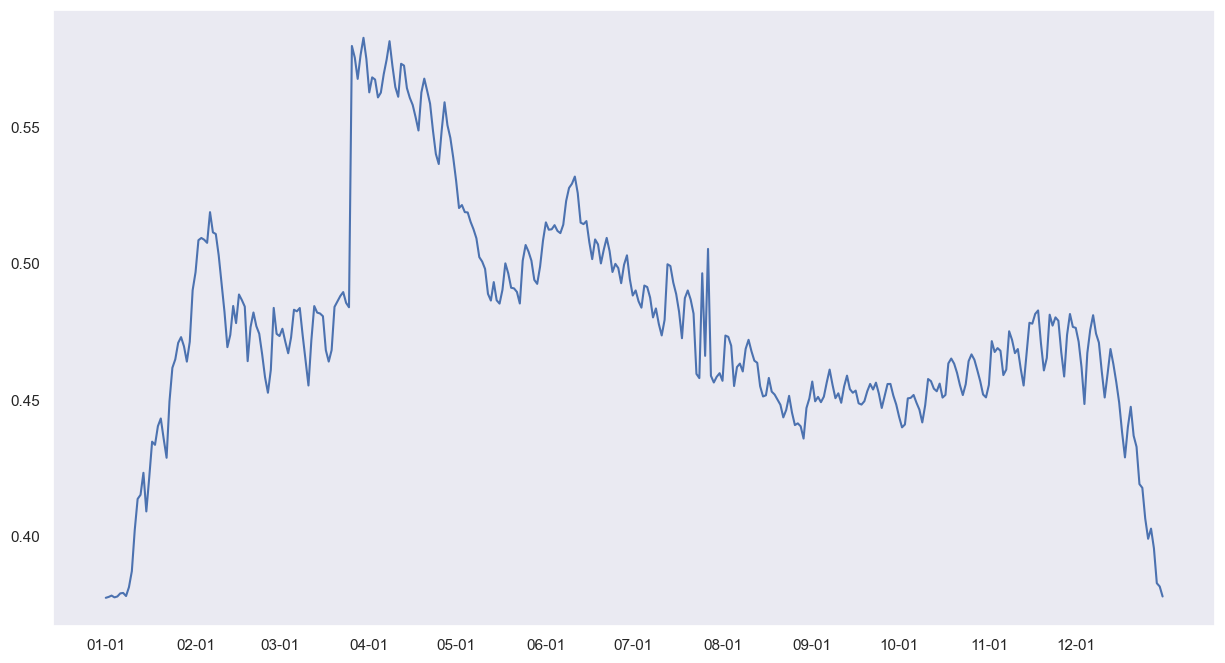

In [19]:
year("val")

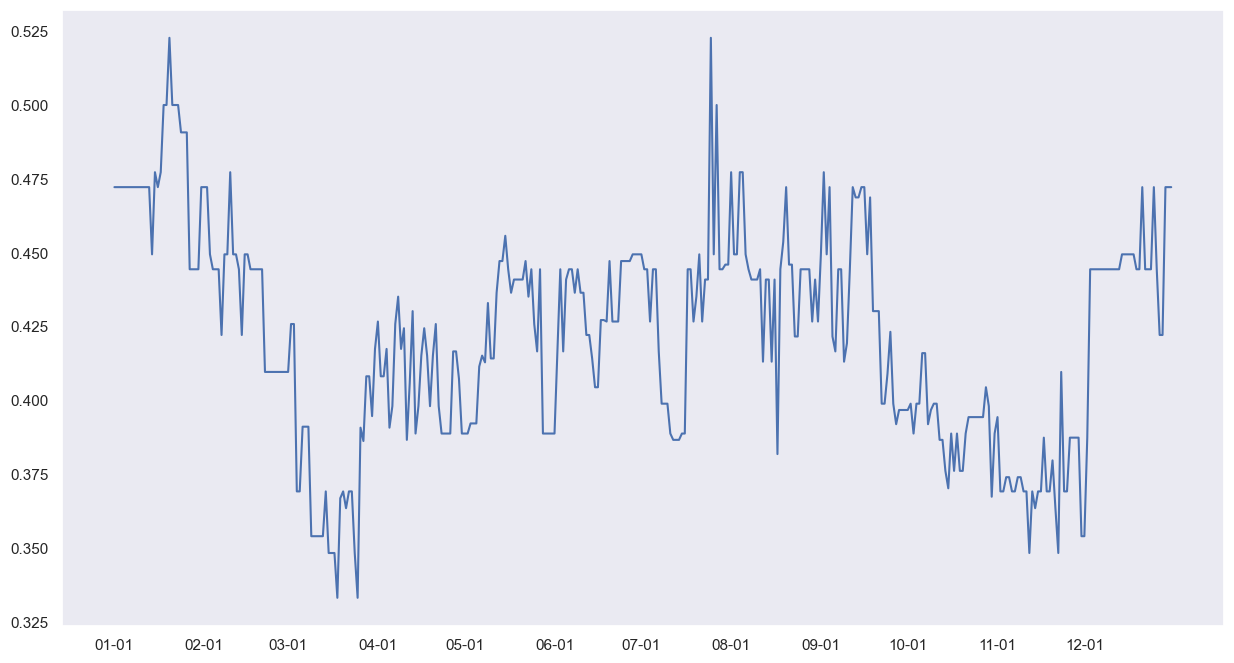

In [20]:
year("val_noexp")

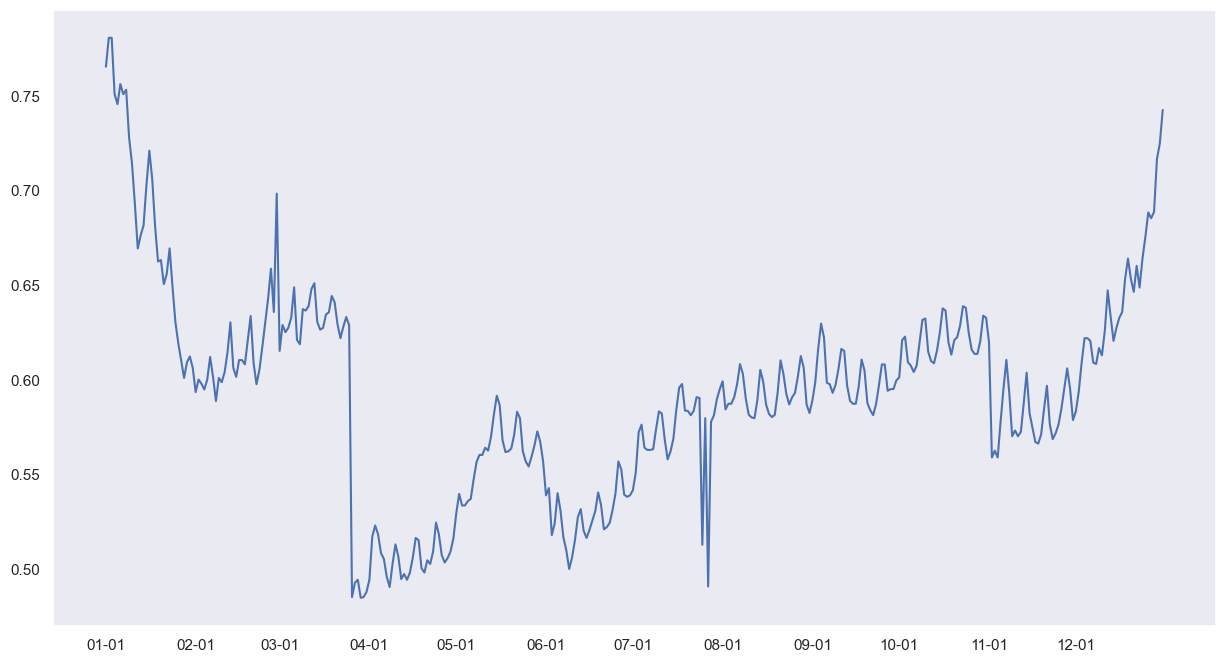

In [21]:
year("res_vac")

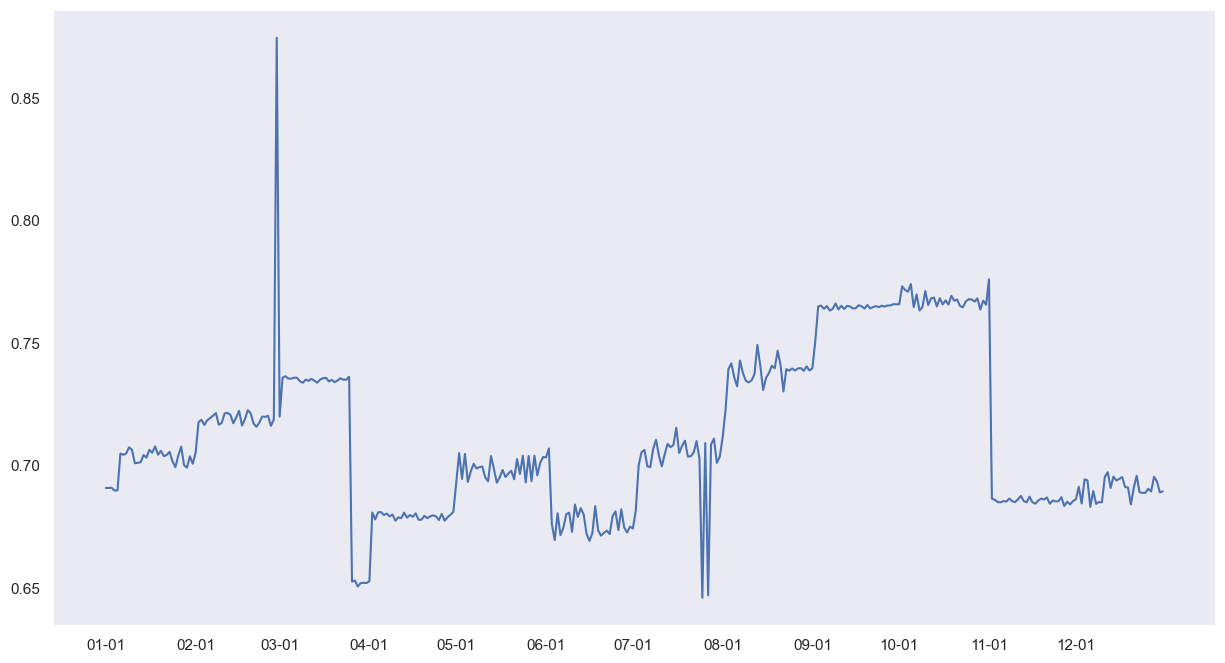

In [22]:
year("res")

In [23]:
def graphs(column, window):
    colmns = langs[column].columns
    langs1 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        
        if col[:2] != 'Py':
            ax.plot(langs1[i])
            labels.append(langs1[i].name)
            col = i
        else:
            ax.plot(langs1[i], linestyle='--')
            labels.append(langs1[i].name)
            col = 'Py'

    ax.legend(labels)
    #plt.xticks('')

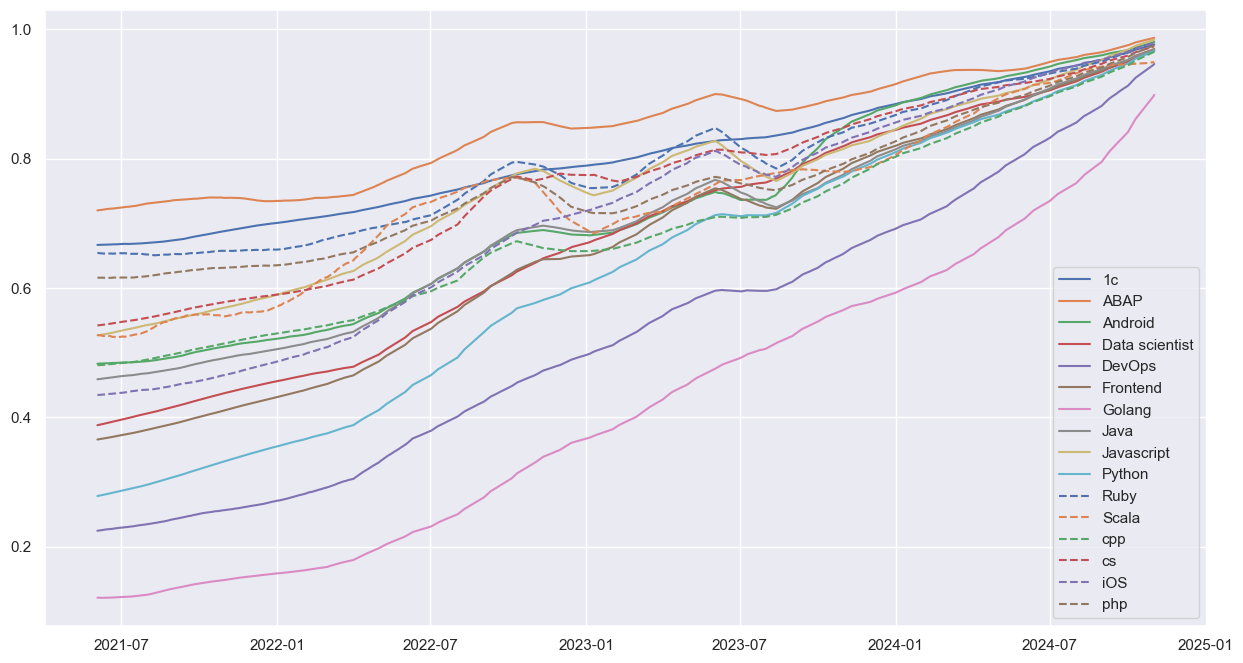

In [24]:
graphs("res", 70)